### Smart Room Cooling System

In [1]:
import numpy as np
from sklearn.linear_model import Perceptron
import matplotlib.pyplot as plt

In [2]:
# Dataset

# Features:
# x1 = Window Open
# x2 = Temperature High

X = np.array([[0,0],[0,1],[1,0],[1,1]])

# Labels:
# 0 = Fan OFF
# 1 = Fan ON
y = np.array([0,1,1,0])

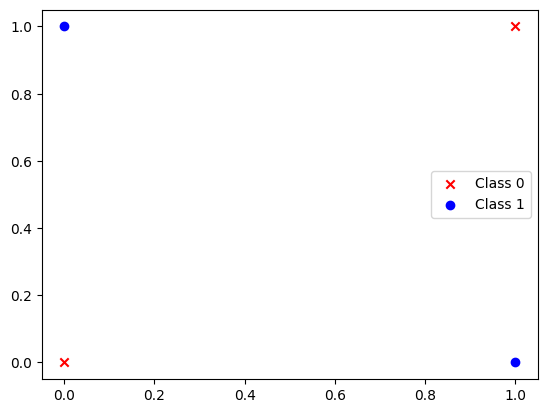

In [3]:
# Plot the points
for i in range(len(X)):
    if y[i]==0:
        plt.scatter(X[i,0],X[i,1], marker='x', color='red', label='Class 0' if i==0 else "")

    else:
        plt.scatter(X[i,0],X[i,1], marker='o', color='blue', label='Class 1' if i==1 else "")

plt.legend()

##### In the above graph we can that see it cannot be seperated using linear classifier. We have to go from 2d to 3d for seperation.

In [4]:
# Feature Transformation
x3 = (X[:,0]*X[:,1]).reshape(-1,1)

# Expand to 3d
X_new = np.hstack((X,x3))

print("Transformed Features: ")
print(X_new)

Transformed Features: 
[[0 0 0]
 [0 1 0]
 [1 0 0]
 [1 1 1]]


In [5]:
# Train linear classifier
model = Perceptron(max_iter=500)
model.fit(X_new,y)

# Predictions
pred = model.predict(X_new)
print("\nPredictions: ")
print(pred)

# Accuracy
acc = model.score(X_new,y)
print("\nAccuracy: ")
print(acc)

# Weights and bias
w = model.coef_[0]
b = model.intercept_[0]

print("\nWeights:", w)
print("Bias:", b)


Predictions: 
[0 1 1 0]

Accuracy: 
1.0

Weights: [ 2.  2. -5.]
Bias: -1.0


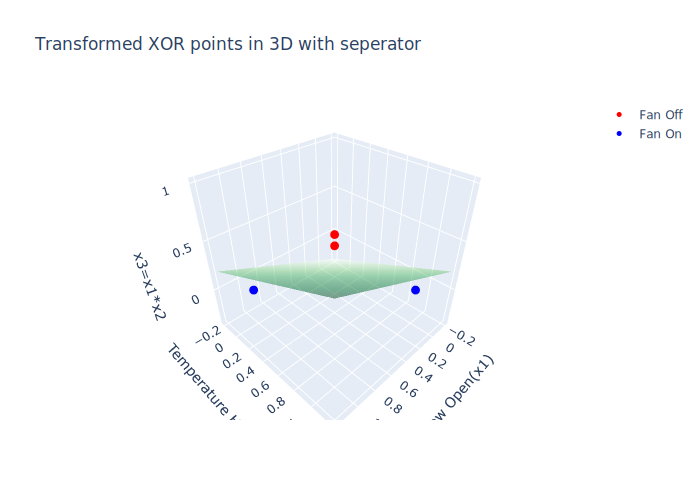

In [6]:
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "svg"

# Create a Plotly figure
fig = go.Figure()

# Add the points to the plot
fig.add_trace(go.Scatter3d(x=X_new[y==0, 0], y=X_new[y==0, 1], z=X_new[y==0, 2],
                           mode='markers', marker=dict(color='red', size=5), name='Fan Off'))

fig.add_trace(go.Scatter3d(x=X_new[y==1, 0], y=X_new[y==1, 1], z=X_new[y==1, 2],
                           mode='markers', marker=dict(color='blue', size=5), name='Fan On'))

# Define the seperator plane
xx,yy = np.meshgrid(np.linspace(-0.2,1.2,20), np.linspace(-0.2,1.2,20))
zz = (-w[0]*xx - w[1]*yy - b) / w[2]
fig.add_trace(go.Surface(x=xx,y=yy, z=zz, opacity=0.5, colorscale='Greens',showscale=False, name='Decision Boundary'))

# Set the layout for better view
fig.update_layout(title='Transformed XOR points in 3D with seperator',
                  scene=dict(xaxis_title='Window Open(x1)', yaxis_title='Temperature High(x2)', zaxis_title='x3=x1*x2'),
                  width=700, height=500)

# Show the figure
fig.show()